/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:418: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=10 observations were given.
  return hypotest_fun_in(*args, **kwds)


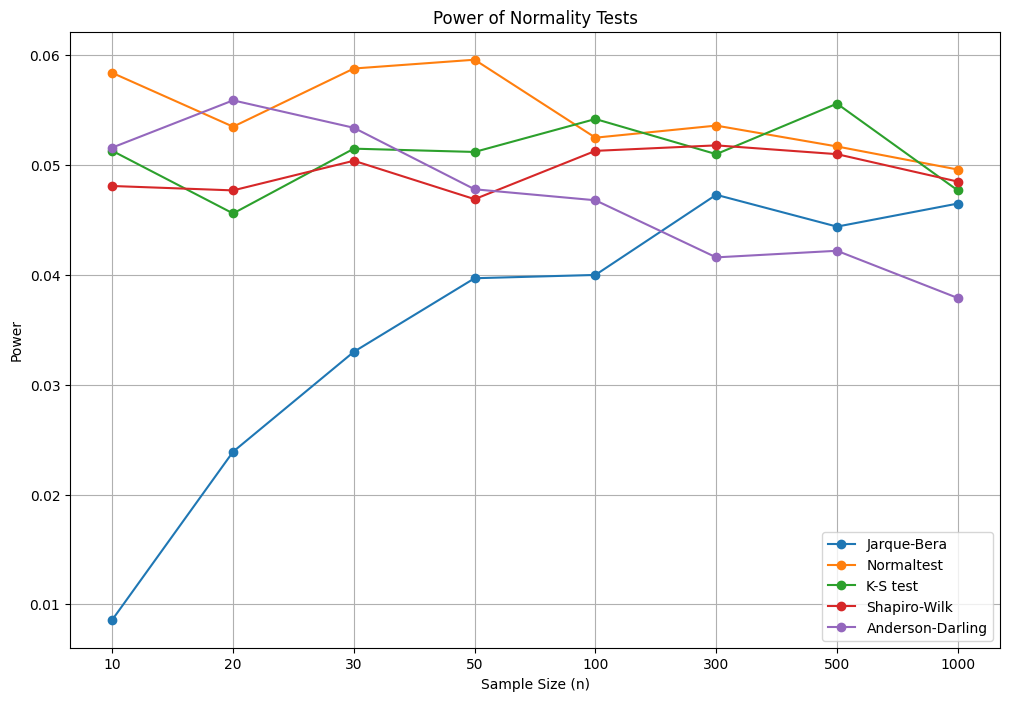

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis, jarque_bera, normaltest, kstest, shapiro, anderson

# 設定實驗參數
N = 10000  # 重複實驗次數
n_values = [10, 20, 30, 50, 100, 300, 500, 1000]  # 樣本大小
alpha = 0.05  # 顯著性水平
power_values = {
    'Jarque-Bera': [],
    'Normaltest': [],
    'K-S test': [],
    'Shapiro-Wilk': [],
    'Anderson-Darling': []
}

# 進行實驗
for n in n_values:
    power_jarque_bera = 0
    power_normaltest = 0
    power_kstest = 0
    power_shapiro = 0
    power_anderson = 0
    
    for _ in range(N):
        x = np.random.normal(0, 1, n)
        s = skew(x)
        k = kurtosis(x, fisher=)
        G1 = np.sqrt(n / 6) * s
        G2 = np.sqrt(n / 24) * (k)
        G3 = G1**2 + G2**2
        
        # Jarque-Bera test
        _, p_jb = jarque_bera(x)
        if p_jb < alpha:
            power_jarque_bera += 1
        
        # D’Agostino and Pearson’s test
        _, p_nt = normaltest(x)
        if p_nt < alpha:
            power_normaltest += 1
        
        # Kolmogorov-Smirnov test
        _, p_ks = kstest(x, 'norm')
        if p_ks < alpha:
            power_kstest += 1
        
        # Shapiro-Wilk test
        _, p_sw = shapiro(x)
        if p_sw < alpha:
            power_shapiro += 1
        
        # Anderson-Darling test
        result_anderson = anderson(x)
        if result_anderson.statistic > result_anderson.critical_values[2]:  # 使用 5% 顯著性水平
            power_anderson += 1
    
    power_values['Jarque-Bera'].append(power_jarque_bera / N)
    power_values['Normaltest'].append(power_normaltest / N)
    power_values['K-S test'].append(power_kstest / N)
    power_values['Shapiro-Wilk'].append(power_shapiro / N)
    power_values['Anderson-Darling'].append(power_anderson / N)

# 繪製折線圖
plt.figure(figsize=(12, 8))
x_positions = np.arange(len(n_values))  # x 軸平均分配的位置
for test_name, power_vals in power_values.items():
    plt.plot(x_positions, power_vals, marker='o', label=test_name)

plt.xticks(x_positions, n_values)  # 設置 x 軸標籤為樣本大小
plt.xlabel('Sample Size (n)')
plt.ylabel('Power')
plt.title('Power of Normality Tests')
plt.legend()
plt.grid(True)
plt.show()

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:418: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=10 observations were given.
  return hypotest_fun_in(*args, **kwds)


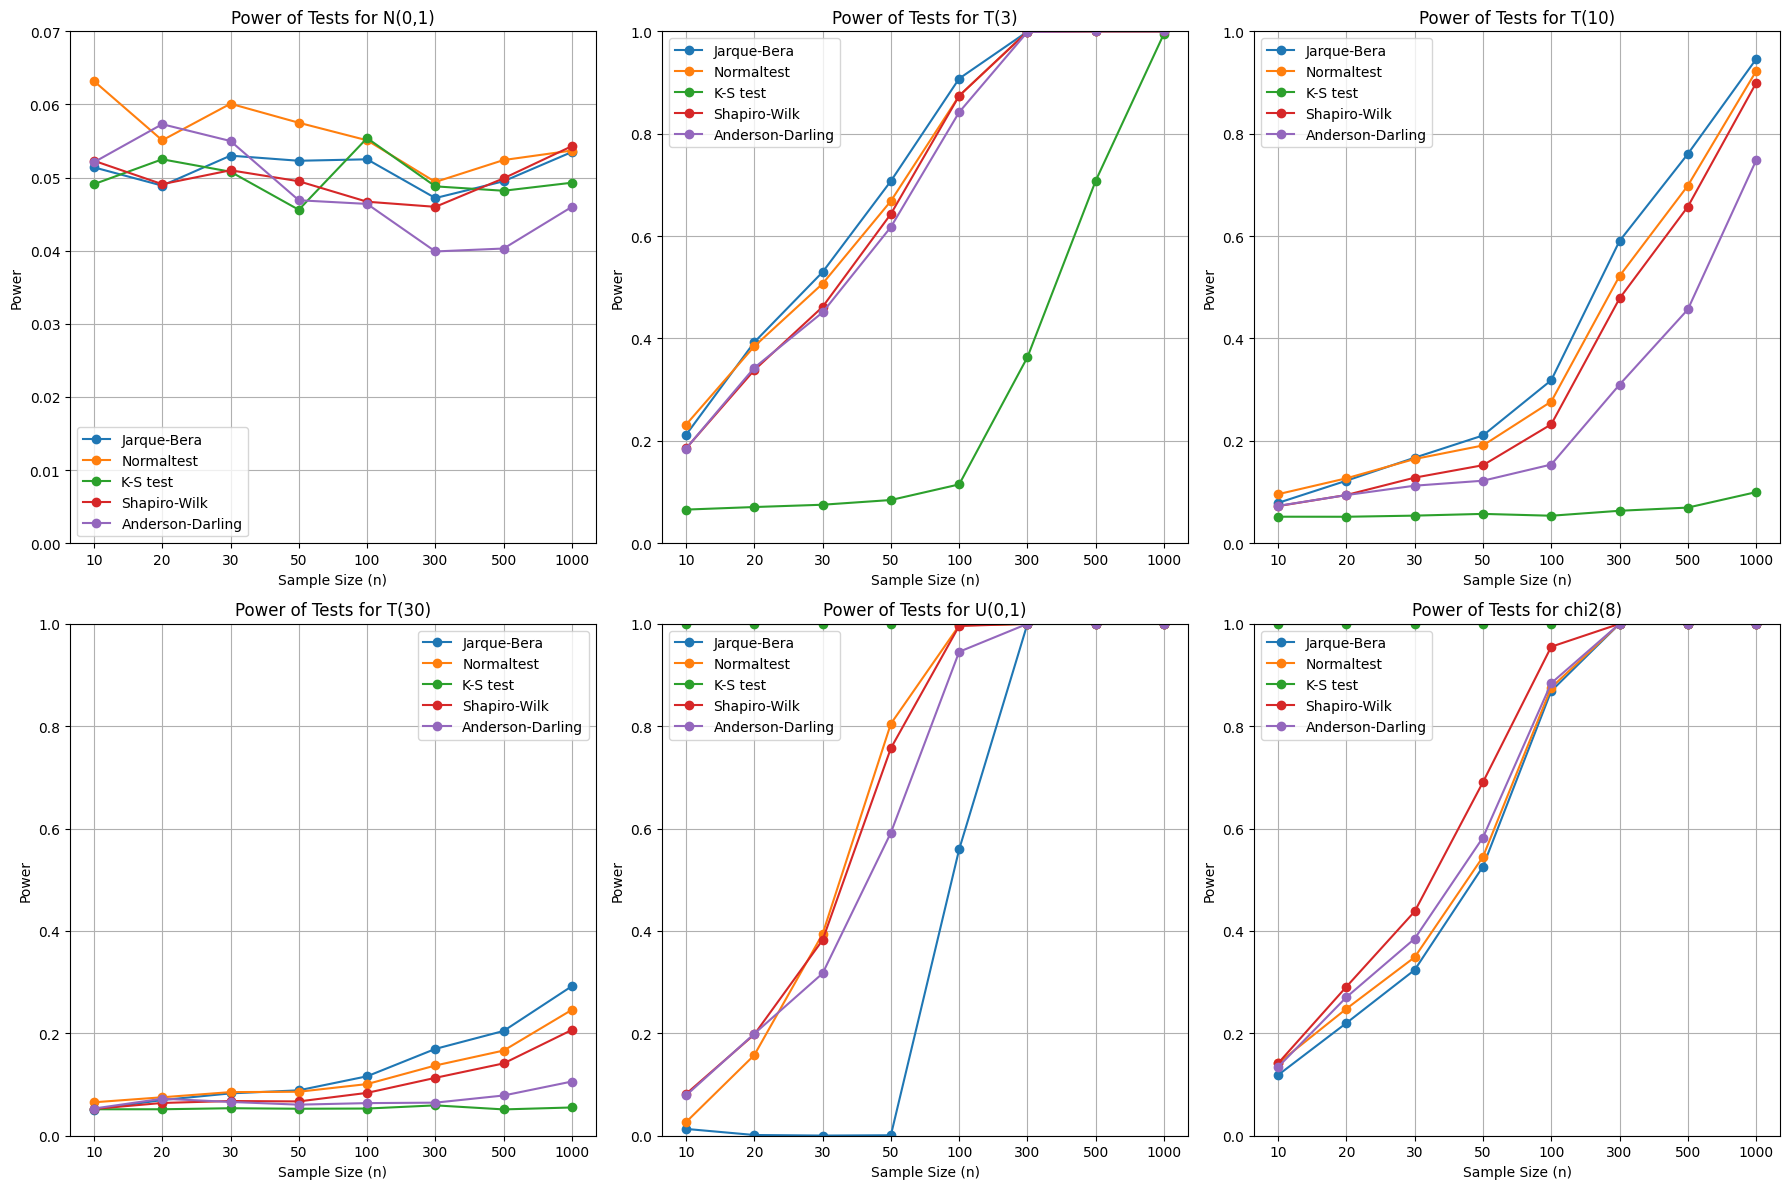

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis, jarque_bera, normaltest, kstest, shapiro, anderson, t, uniform, chi2

def JB_test(x):
    """
    檢驗資料是否來自常態分佈的 Jarque-Bera 檢定。
    
    參數:
    x : array_like
        欲檢定是否為常態的一組資料。
    
    返回:
    stats : float
        G_3 檢定統計量的值。
    p_value : float
        檢定的 p-value。
    """
    n = x.shape[1]
    G1 = np.sqrt(n / 6) * skew(x, axis=1, bias=False)
    G2 = np.sqrt(n / 24) * (kurtosis(x, axis=1, fisher=True, bias =False) )
    G3 = G1**2 + G2**2
    p_value = 1 - chi2.cdf(G3, df=2)
    return G3, p_value

# 定義分佈母體
distributions = {
    'N(0,1)': lambda size: np.random.normal(0, 1, size),
    'T(3)': lambda size: t.rvs(df=3, size=size),
    'T(10)': lambda size: t.rvs(df=10, size=size),
    'T(30)': lambda size: t.rvs(df=30, size=size),
    'U(0,1)': lambda size: uniform.rvs(0, 1, size=size),
    'chi2(8)': lambda size: chi2.rvs(df=8, size=size)
}

# 設定實驗參數
N = 10000  # 重複實驗次數
n_values = [10, 20, 30, 50, 100, 300, 500, 1000]  # 樣本大小
alpha = 0.05  # 顯著性水平

# 儲存結果
power_results = {dist: {test: [] for test in ['Jarque-Bera', 'Normaltest', 'K-S test', 'Shapiro-Wilk', 'Anderson-Darling']} for dist in distributions.keys()}

# 進行實驗
for dist_name, dist_func in distributions.items():
    for n in n_values:
        x = dist_func((N, n))  # 生成 N 個樣本，每個樣本大小為 n
        
        # Jarque-Bera test
        _, p_jb = JB_test(x)
        power_jarque_bera = np.mean(p_jb < alpha)
        
        # D’Agostino and Pearson’s test
        _, p_nt = normaltest(x, axis=1)
        power_normaltest = np.mean(p_nt < alpha)
        
        # Kolmogorov-Smirnov test
        p_ks = np.array([kstest(x[i], 'norm')[1] for i in range(N)])
        power_kstest = np.mean(p_ks < alpha)
        
        # Shapiro-Wilk test
        p_sw = np.array([shapiro(x[i])[1] for i in range(N)])
        power_shapiro = np.mean(p_sw < alpha)
        
        # Anderson-Darling test
        power_anderson = np.mean([anderson(x[i]).statistic > anderson(x[i]).critical_values[2] for i in range(N)])
        
        power_results[dist_name]['Jarque-Bera'].append(power_jarque_bera)
        power_results[dist_name]['Normaltest'].append(power_normaltest)
        power_results[dist_name]['K-S test'].append(power_kstest)
        power_results[dist_name]['Shapiro-Wilk'].append(power_shapiro)
        power_results[dist_name]['Anderson-Darling'].append(power_anderson)

# 繪製六張小圖
fig, axs = plt.subplots(2, 3, figsize=(18, 12))
x_positions = np.arange(len(n_values))  # x 軸平均分配的位置

for i, (dist_name, power_vals) in enumerate(power_results.items()):
    ax = axs[i // 3, i % 3]
    for test_name, powers in power_vals.items():
        ax.plot(x_positions, powers, marker='o', label=test_name)
    ax.set_xticks(x_positions)
    ax.set_xticklabels(n_values)
    ax.set_xlabel('Sample Size (n)')
    ax.set_ylabel('Power')
    if i == 0:
        ax.set_ylim(0, 0.07)  # 設置第一張圖的 y 軸範圍
    else:
        ax.set_ylim(0, 1)  # 設置其他圖的 y 軸範圍
    ax.set_title(f'Power of Tests for {dist_name}')
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

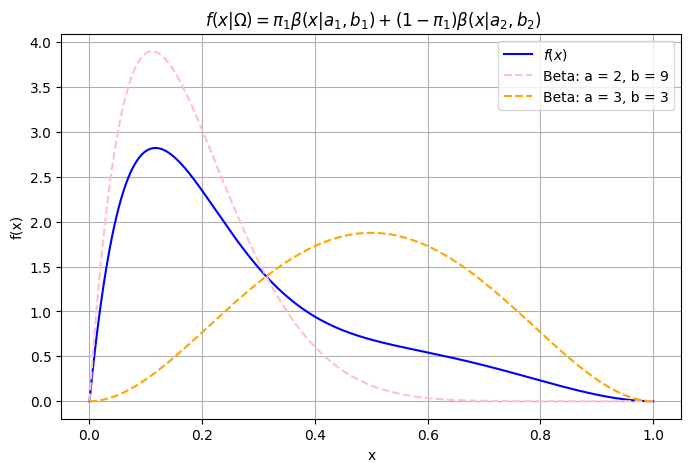

In [27]:
# draw a mixed beta distribution with beta(a1, b1) and beta(a2, b2) 
import matplotlib.pyplot as plt
import numpy as np  
from scipy.stats import beta
import scipy.stats as stats

a1, b1 = 2, 9
a2, b2 = 3, 3
f = lambda x: 0.7 * stats.beta.pdf(x, a1, b1) + 0.3 * stats.beta.pdf(x, a2, b2)
x = np.linspace(0, 1, 1000)
y = f(x)
fig = plt.figure( figsize=(8, 5))
plt.plot(x, y, label='$f(x)$', color='blue')     
plt.grid()
plt.plot( x, beta.pdf(x, a1, b1), label= f'Beta: a = {a1}, b = {b1}', color='pink', linestyle='--') 
plt.plot( x, beta.pdf(x, a2, b2), label= f'Beta: a = {a2}, b = {b2}', color='orange', linestyle='--')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title(' $f(x|\\Omega) = \\pi_1 \\beta(x|a_1,b_1) + (1 - \\pi_1) \\beta(x|a_2, b_2)$ ')
plt.legend()
plt.show()


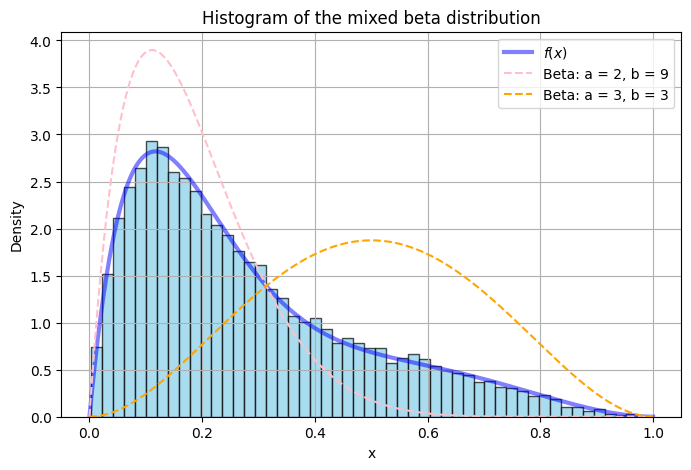

In [38]:
import matplotlib.pyplot as plt
import numpy as np  
from scipy.stats import beta
from scipy.stats import binom
import scipy.stats as stats
a1, b1 = 2, 9
a2, b2 = 3, 3
pi1 = 0.7

# generate random samples from the mixed beta distribution
N = 10000
n1 = binom.rvs(1, pi1)  
x1 = beta.rvs(a1, b1, size=int(N*pi1))
x2 = beta.rvs(a2, b2, size=N-len(x1))
x_all = np.concatenate((x1, x2))

f= lambda x: pi1 * stats.beta.pdf(x, a1, b1) + (1-pi1) * stats.beta.pdf(x, a2, b2)
x = np.linspace(0, 1, 1000)
y = f(x)
fig = plt.figure( figsize=(8, 5))
plt.plot(x, y, label='$f(x)$', color='blue', linewidth=3, alpha=0.5)
plt.plot( x, beta.pdf(x, a1, b1), label= f'Beta: a = {a1}, b = {b1}', color='pink', linestyle='--')
plt.plot( x, beta.pdf(x, a2, b2), label= f'Beta: a = {a2}, b = {b2}', color='orange', linestyle='--')   
plt.grid()
plt.hist(x_all, bins=50, density=True, color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Histogram of the mixed beta distribution')
plt.xlabel('x')
plt.ylabel('Density')
plt.legend()
plt.xlim
plt.show()

[0.71241164 1.97916827 8.79920932 3.42568535 3.24024679]


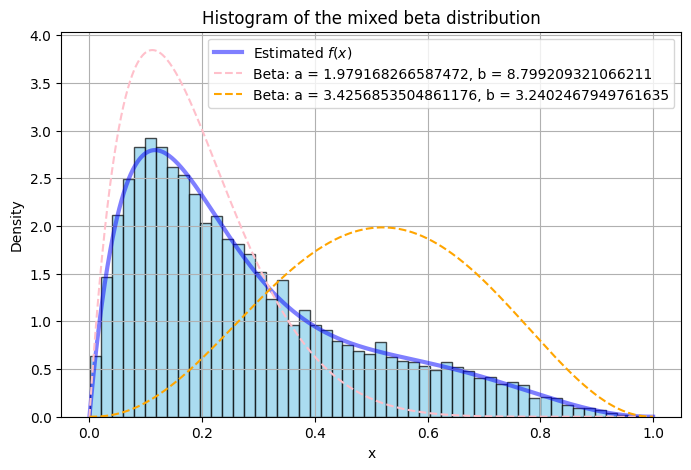

In [40]:
# compute MLE of the mixture of two beta distributions from the random samples
import numpy as np
from scipy.optimize import minimize
from scipy.stats import beta
from scipy.stats import binom
import scipy.stats as stats

# generate random samples from the mixed beta distribution
N = 10000
n1 = binom.rvs(1, pi1)
x1 = beta.rvs(a1, b1, size=int(N*pi1))
x2 = beta.rvs(a2, b2, size=N-len(x1))
x_all = np.concatenate((x1, x2))

# minimize the negative log-likelihood function 
def neg_log_likelihood(params):
    pi, a1, b1, a2, b2 = params
    return -np.sum(np.log(pi * beta.pdf(x_all, a1, b1) + (1-pi) * beta.pdf(x_all, a2, b2)))

# initial guess of the parameters
params0 = [0.5, 1, 6, 2, 2] 
bnd = ((0, 1), (0, None), (0, None), (0, None), (0, None))  
result = minimize(neg_log_likelihood, params0, bounds=bnd)  

print(result.x)

#plot the estimated distribution
pi, a1, b1, a2, b2 = result.x
f= lambda x: pi * stats.beta.pdf(x, a1, b1) + (1-pi) * stats.beta.pdf(x, a2, b2)
x = np.linspace(0, 1, 1000)
y = f(x)
fig = plt.figure( figsize=(8, 5))
plt.plot(x, y, label='Estimated $f(x)$', color='blue', linewidth=3, alpha=0.5)
plt.plot( x, beta.pdf(x, a1, b1), label= f'Beta: a = {a1}, b = {b1}', color='pink', linestyle='--')
plt.plot( x, beta.pdf(x, a2, b2), label= f'Beta: a = {a2}, b = {b2}', color='orange', linestyle='--')
plt.grid()
plt.hist(x_all, bins=50, density=True, color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Histogram of the mixed beta distribution')
plt.xlabel('x')
plt.ylabel('Density')
plt.legend()
plt.show()

